# 02 — Обов'язкові порівняння моделей

**Чекпоінти:** Baseline (0.25), Decision Tree (1.00), Random Forest (1.00), XGBoost (1.00) — разом 3.25 бала.

## Правила, однакові для всього ноутбука

| | |
|---|---|
| **Дані** | `train_dev.parquet`, 396 900 рядків. Holdout не читається |
| **Фічі** | базовий набір **v0** — ті самі 15 фіч для всіх моделей (`config.FEATURES_V0`) |
| **Фолди** | `KFold(5, shuffle=True, random_state=42)` з `cv.get_folds('A')` |
| **Метрика** | RMSE |
| **Оцінювання** | тільки через `cv.run_cv()` — усі числа отримані однаково |

Міняється **одна річ за раз**. Коли порівнюються моделі — фічі зафіксовані; коли
в ноутбуці 03 порівнюватимуться фічі — модель буде зафіксована.

## Два протоколи обчислень

Перебір гіперпараметрів на повних даних × 5 фолдів не вкладається в бюджет CPU
(особливо Random Forest). Тому:

- **Protocol A** — 5 фолдів, 396 900 рядків. Усі числа в підсумкових таблицях.
- **Protocol B** — 3 фолди, підвибірка 150 000 (`random_state=42`). Лише щоб
  **упорядкувати** конфігурації між собою.

Переможець пошуку **завжди** переміряється за Protocol A перед тим, як потрапити
в порівняльну таблицю. Числа з двох протоколів ніколи не порівнюються між собою.

## Препроцесинг

Один і той самий для всіх обов'язкових порівнянь:

- числові: `SimpleImputer(median)`, для лінійних моделей додатково `StandardScaler`;
- категоріальні: `SimpleImputer(most_frequent)` + `OneHotEncoder(handle_unknown='ignore')`.

Усе це всередині `sklearn.Pipeline`, тобто навчається **в межах навчальної частини
кожного фолду**. Скейлінг для дерев вимкнено: вони інваріантні до монотонних
перетворень, тож це був би витрачений час без зміни результату.

In [1]:
import sys, time, warnings
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from xgboost import XGBRegressor

import config as C
import cv as CV
import data as D
import viz
from features import make_preprocessor

viz.set_style()
pd.set_option('display.width', 150); pd.set_option('display.max_columns', 40)

train = D.load_train_dev()
X, y = D.xy(train)                      # фіче-сет v0: 15 фіч, без record_id і таргета
print(f'X: {X.shape}   y: {y.shape}')

# Підвибірка для Protocol B — фіксована, щоб усі пошуки йшли на тих самих рядках
idx_B = train.sample(C.SEARCH_SAMPLE, random_state=C.SEED).index
X_B, y_B = X.loc[idx_B], y.loc[idx_B]
print(f'Protocol B: {X_B.shape}, {CV.get_folds("B").get_n_splits()} фолди')

X: (396900, 15)   y: (396900,)
Protocol B: (150000, 15), 3 фолди


In [2]:
# Фабрики моделей. run_cv приймає саме ФАБРИКУ (callable без аргументів), а не
# готовий об'єкт: інакше на другому фолді модель дофітувалася б поверх стану з
# першого, і валідаційні рядки першого фолду вже брали б участь у навчанні.

def linear_pipe(model):
    return lambda: Pipeline([('prep', make_preprocessor(scale=True)), ('model', model())])

def tree_pipe(model):
    # scale=False: дерева інваріантні до монотонних перетворень
    return lambda: Pipeline([('prep', make_preprocessor(scale=False)), ('model', model())])

def show(df, cols=None):
    cols = cols or ['name', 'protocol', 'mean_rmse', 'std_rmse', 'oof_rmse',
                    'train_rmse', 'overfit_gap', 'fit_seconds']
    return df[cols].round(4)

## 1. Baseline (0.25 бала)

Дві моделі: константа і лінійна регресія. Константа задає межу, гіршою за яку бути
не можна; лінійна регресія — першу осмислену точку відліку.

### 1.1. Константний прогноз

У кожному фолді передбачаємо **середнє таргета по навчальній частині цього фолду**,
а не глобальне середнє по всьому `train_dev`. Різниця невелика за величиною, але
принципова: глобальне середнє порахувало б і валідаційні рядки, тобто було б
витоком — хай і нешкідливим.

`DummyRegressor(strategy='mean')` робить саме це: `.fit()` запам'ятовує середнє
навчальних даних, `.predict()` повертає його.

In [3]:
oof_const, _ = CV.run_cv(lambda: DummyRegressor(strategy='mean'), X, y,
                         name='00_constant_mean', protocol='A',
                         params={'strategy': 'mean'})
print(f"\nσ таргета: {y.std():.4f}  — RMSE константи дорівнює їй за побудовою")

  fold 1/5  val 18.9999  train 18.8978  0.0s
  fold 2/5  val 18.8936  train 18.9245  0.0s
  fold 3/5  val 18.9005  train 18.9227  0.0s
  fold 4/5  val 18.8770  train 18.9286  0.0s
  fold 5/5  val 18.9207  train 18.9177  0.0s
[00_constant_mean]  OOF 18.9184  |  mean 18.9183 ± 0.0431  |  train 18.9183  (gap +0.0001)  |  0s

σ таргета: 18.9183  — RMSE константи дорівнює їй за побудовою


**Висновок.** RMSE = 18.9183, що з точністю до округлення дорівнює стандартному
відхиленню таргета.

Це не збіг, а тотожність. RMSE константи $c$ — це $\sqrt{\frac{1}{n}\sum(y_i - c)^2}$.
Мінімум по $c$ досягається при $c = \bar{y}$, і тоді вираз перетворюється на формулу
стандартного відхилення. Тобто **константний базлайн вимірює, наскільки таргет
розкиданий сам по собі**, без жодної моделі.

Будь-яка подальша модель відповідає на питання: наскільки фічі зменшують цей розкид.

### 1.2. Лінійна регресія

Препроцесинг (усе всередині `Pipeline`, тобто fit лише на навчальній частині фолду):

| колонки | що робимо | навіщо |
|---|---|---|
| числові | `SimpleImputer(median)` | 3% пропусків; медіана стійка до викидів, яких у `study_time` вистачає |
| числові | `StandardScaler` | щоб коефіцієнти були порівнювані між собою |
| категоріальні | `SimpleImputer(most_frequent)` | 2% пропусків |
| категоріальні | `OneHotEncoder(handle_unknown='ignore')` | модель приймає лише числа |

`handle_unknown='ignore'` обов'язковий: навчальний фолд — це 80% даних, і рідкісна
категорія теоретично може в нього не потрапити.

In [4]:
oof_lin, _ = CV.run_cv(linear_pipe(LinearRegression), X, y,
                       name='01_linear_regression', protocol='A',
                       params={'model': 'LinearRegression', 'scale': True})

  fold 1/5  val 9.2833  train 9.2361  0.7s


  fold 2/5  val 9.2097  train 9.2545  0.6s


  fold 3/5  val 9.2371  train 9.2477  0.6s


  fold 4/5  val 9.2499  train 9.2445  0.6s


  fold 5/5  val 9.2580  train 9.2460  0.6s
[01_linear_regression]  OOF 9.2476  |  mean 9.2476 ± 0.0242  |  train 9.2458  (gap +0.0018)  |  3s


In [5]:
# Коефіцієнти: навчаємо на всіх train_dev лише для інтерпретації,
# самі числа RMSE беруться з CV вище.
pipe = linear_pipe(LinearRegression)()
pipe.fit(X, y)
names = pipe.named_steps['prep'].get_feature_names_out()
coef = pd.Series(pipe.named_steps['model'].coef_, index=names)

print(f'intercept: {pipe.named_steps["model"].intercept_:.4f}')
print(f'\nнайбільші за модулем коефіцієнти ({len(coef)} усього):')
print(coef.reindex(coef.abs().sort_values(ascending=False).index).head(14).round(3).to_string())

intercept: 62.5052

найбільші за модулем коефіцієнти (45 усього):
study_minutes                     8.399
learning_routine_coaching         5.448
rest_quality_poor                -4.396
rest_quality_good                 4.338
engagement_index                  4.288
campus_resources_low             -3.678
campus_resources_high             3.655
learning_routine_self-study      -3.272
attendance_rate                   2.465
learning_routine_online videos   -2.355
study_time                        2.347
sleep_duration                    2.288
learning_routine_mixed            1.484
learning_routine_group study     -1.305


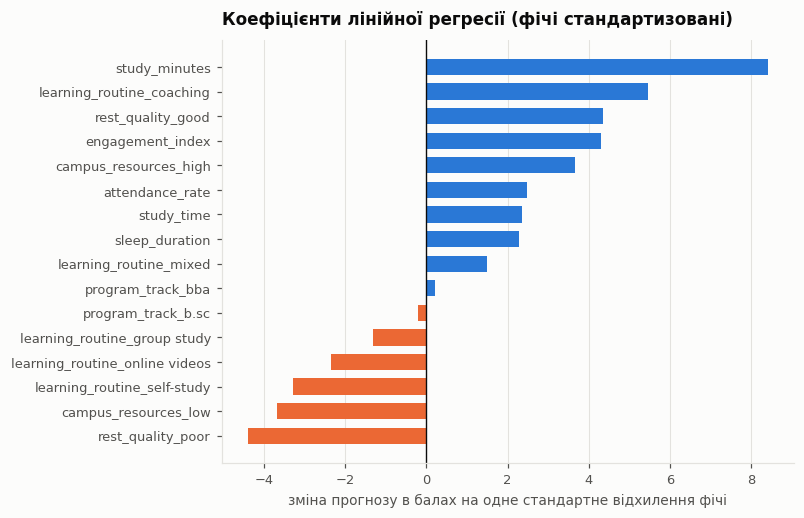

In [6]:
fig, ax = plt.subplots(figsize=(7.4, 4.8))
top = coef.reindex(coef.abs().sort_values(ascending=False).index).head(16).sort_values()
colors = [viz.ORANGE if v < 0 else viz.BLUE for v in top.values]
ax.barh(top.index, top.values, color=colors, height=0.66)
ax.axvline(0, color=viz.INK, linewidth=0.9)
ax.set_title('Коефіцієнти лінійної регресії (фічі стандартизовані)')
ax.set_xlabel('зміна прогнозу в балах на одне стандартне відхилення фічі')
ax.grid(axis='x'); ax.grid(axis='y', visible=False)
plt.tight_layout(); plt.show()

### 1.3. Що означають коефіцієнти та інтерсепт

Фічі стандартизовані, тому коефіцієнт $\beta_j$ читається так: **на скільки балів
зміниться прогноз, якщо фіча $j$ зросте на одне своє стандартне відхилення, за
незмінних інших фіч**.

**Інтерсепт** — прогноз при всіх стандартизованих фічах, рівних нулю, тобто для
«середнього» студента. Він має вийти близьким до середнього таргета 62.51.

Для one-hot колонок логіка інша: коефіцієнт — це зсув відносно решти категорій
тієї ж фічі (базова категорія розчинена в інтерсепті, бо `OneHotEncoder` тут без
`drop`). Тому їх коректно порівнювати між собою всередині однієї фічі, а не з
числовими коефіцієнтами.

Результат узгоджується з EDA: зверху `study_minutes` і `study_time`, далі
`attendance_rate`, потім категорії `learning_routine` і `rest_quality`.
`intake_marker` і `learner_age` біля нуля.

### 1.4. Обмеження лінійної регресії на цих даних

**1. Адитивність — модель не бачить взаємодій.**
Прогноз — сума незалежних внесків. Модель не може виразити «висока відвідуваність
допомагає тільки за достатнього сну»: для цього добуток фіч треба додати руками.
Дерева такі взаємодії знаходять самі, двома послідовними сплітами. Це найсуттєвіше
обмеження лінійної моделі тут.

**2. Мультиколінеарність — присутня, але перевіримо, чи вона шкодить.**
EDA (§7.1 ноутбука 01) показав: VIF `engagement_index` = 23.2, `study_minutes` = 18.4,
`attendance_rate` = 12.1 при тривожному порозі 10, бо `engagement_index` на 95.7%
є лінійною комбінацією інших фіч.

Стандартний підручниковий наслідок — нестабільні коефіцієнти. Але VIF показує
**у скільки разів** роздувається дисперсія коефіцієнта, а не яка вона в абсолютних
числах. Тому питання відкрите, і його треба вимірювати, а не постулювати: перевіряємо
нижче розкидом коефіцієнтів по фолдах.

**3. Чутливість до викидів.**
EDA знайшов `attendance_rate` до 150 при σ = 17.6 і `study_time` до 32.24 год при
σ = 2.5. Метод найменших квадратів штрафує квадрат помилки, тому один далекий рядок
тягне пряму сильніше за сотню звичайних. Дерева до цього байдужі: для них важливий
лише порядок значень, а не наскільки далеко лежить викид. Це дає конкретне
передбачення для ноутбука 03 — виправлення `study_time` має помітно допомогти
лінійній моделі й майже не вплинути на дерева.

### 1.5. Чи справді коефіцієнти нестабільні?

Пряма перевірка: навчаємо лінійну регресію на кожному з п'яти навчальних фолдів
окремо і дивимось, наскільки розходяться коефіцієнти. Якщо мультиколінеарність
шкодить, фічі з високим VIF мають «стрибати» від фолду до фолду.

In [7]:

coefs = []
for trn, _ in CV.get_folds('A').split(X):
    p = linear_pipe(LinearRegression)().fit(X.iloc[trn], y.iloc[trn])
    coefs.append(pd.Series(p.named_steps['model'].coef_,
                           index=p.named_steps['prep'].get_feature_names_out()))
cf = pd.DataFrame(coefs)

watch = ['study_minutes', 'study_time', 'attendance_rate', 'engagement_index',
         'sleep_duration', 'intake_marker']
stab = pd.DataFrame({
    'VIF (з EDA)': [18.4, 10.0, 12.1, 23.2, 1.0, 1.0],
    'середній коеф.': cf[watch].mean(),
    'std по фолдах': cf[watch].std(),
    'розкид, %': cf[watch].std() / cf[watch].mean().abs() * 100,
})
print(stab.round(4).to_string())

sigma, n_fold = y.std(), int(len(X) * 0.8)
print(f'\nтеоретична SE коефіцієнта при VIF=23.2 і n={n_fold}:')
print(f'  SE ~ sigma * sqrt(VIF) / sqrt(n) = {sigma * np.sqrt(23.2) / np.sqrt(n_fold):.4f}')


                  VIF (з EDA)  середній коеф.  std по фолдах  розкид, %
study_minutes            18.4          8.3988         0.0142     0.1693
study_time               10.0          2.3477         0.0089     0.3775
attendance_rate          12.1          2.4665         0.0225     0.9114
engagement_index         23.2          4.2871         0.0254     0.5935
sleep_duration            1.0          2.2877         0.0101     0.4420
intake_marker             1.0          0.0023         0.0072   315.6579

теоретична SE коефіцієнта при VIF=23.2 і n=317520:
  SE ~ sigma * sqrt(VIF) / sqrt(n) = 0.1617



**Висновок — підручниковий наслідок тут не справджується.**

Коефіцієнти фіч із найвищим VIF розходяться по фолдах на **0.2–0.9%** свого значення.
`engagement_index` із VIF = 23.2 має std по фолдах 0.025 при коефіцієнті 4.29. Це не
нестабільність.

Причина в тому, що VIF — **множник**, а не абсолютна величина. Дисперсія коефіцієнта
приблизно $\sigma^2 \cdot \text{VIF} / n$. VIF = 23 роздуває стандартну помилку
приблизно в $\sqrt{23} \approx 4.8$ раза, але при $n = 317\,520$ вихідна помилка
настільки мала, що навіть збільшена в п'ять разів лишається ~0.08 бала.

**Мультиколінеарність тут реальна як властивість даних, але не є практичною
проблемою — її «перебиває» розмір вибірки.** Якби рядків було не 400 тисяч, а 400,
картина була б протилежною.

Єдиний рядок із величезним розкидом — `intake_marker`: 316%. Але його коефіцієнт
0.0023, тобто невідрізненний від нуля, і розкид навколо нуля у відсотках нічого не
означає. Це шумова фіча поводиться рівно так, як передбачив EDA.


### 1.6. Ridge і Lasso

Це **доповнення**, а не заміна обов'язкової `LinearRegression`.

Ridge додає до функції втрат штраф $\alpha\sum\beta_j^2$ — саме той інструмент, який
застосовують проти колінеарності. Зважаючи на 1.5, очікуємо, що він нічого не змінить:
лікувати нема чого.

`alpha` підбирається через `RidgeCV` **всередині** навчальної частини кожного фолду,
внутрішньою крос-валідацією. Якби ми підбирали його на валідаційному фолді, той
перестав би бути незалежним.

In [8]:
ALPHAS = np.logspace(-2, 4, 25)

CV.run_cv(linear_pipe(lambda: RidgeCV(alphas=ALPHAS)), X, y,
          name='02_ridge', protocol='A', params={'alphas': 'logspace(-2,4,25)', 'cv': 'внутрішній RidgeCV'})

CV.run_cv(linear_pipe(lambda: LassoCV(n_alphas=12, cv=3, random_state=C.SEED, max_iter=2000)), X, y,
          name='03_lasso', protocol='A', params={'n_alphas': 12, 'cv': 3});

  fold 1/5  val 9.2833  train 9.2361  1.2s


  fold 2/5  val 9.2097  train 9.2545  1.2s


  fold 3/5  val 9.2371  train 9.2477  1.2s


  fold 4/5  val 9.2498  train 9.2445  1.2s


  fold 5/5  val 9.2580  train 9.2460  1.2s
[02_ridge]  OOF 9.2476  |  mean 9.2476 ± 0.0242  |  train 9.2458  (gap +0.0018)  |  6s


  fold 1/5  val 9.2838  train 9.2371  0.8s


  fold 2/5  val 9.2110  train 9.2555  0.8s


  fold 3/5  val 9.2375  train 9.2487  0.8s


  fold 4/5  val 9.2501  train 9.2455  0.8s


  fold 5/5  val 9.2572  train 9.2471  0.8s
[03_lasso]  OOF 9.2480  |  mean 9.2479 ± 0.0239  |  train 9.2468  (gap +0.0012)  |  4s


In [9]:
# Наскільки Ridge стиснув коефіцієнти колінеарних фіч
ridge = linear_pipe(lambda: RidgeCV(alphas=ALPHAS))(); ridge.fit(X, y)
coef_r = pd.Series(ridge.named_steps['model'].coef_, index=names)

collinear = ['study_minutes', 'study_time', 'attendance_rate', 'engagement_index']
cmp = pd.DataFrame({'LinearRegression': coef[collinear], 'Ridge': coef_r[collinear]}).round(3)
cmp['зміна'] = (cmp.Ridge - cmp.LinearRegression).round(3)
print(f"обраний alpha: {ridge.named_steps['model'].alpha_:.4f}\n")
print(cmp.to_string())
print(f"\nсума |коефіцієнтів| усіх фіч:  LinearRegression {coef.abs().sum():.2f}   Ridge {coef_r.abs().sum():.2f}")

обраний alpha: 31.6228

                  LinearRegression  Ridge  зміна
study_minutes                8.399  8.395 -0.004
study_time                   2.347  2.350  0.003
attendance_rate              2.465  2.464 -0.001
engagement_index             4.288  4.290  0.002

сума |коефіцієнтів| усіх фіч:  LinearRegression 51.39   Ridge 51.38


**Висновок — очікування з 1.5 підтвердилось.**

Ridge обрав `alpha` = 31.6 і змінив коефіцієнти колінеарних фіч на **0.001–0.004**,
тобто в межах четвертого знака. Сума модулів усіх коефіцієнтів: 51.39 → 51.38.
RMSE ідентичний до четвертого знака.

Це не «Ridge не працює» — це «тут нема чого лікувати». При 317 520 рядках на 45 ознак
переобучення лінійної моделі просто не виникає, а коефіцієнти й без регуляризації
стабільні (1.5). Штраф $\alpha\sum\beta_j^2$ з $\alpha = 31.6$ проти суми квадратів
залишків по 317 тисячах рядків — величина третього порядку.

Lasso гірший на 0.0004 — він занулює частину коефіцієнтів, і серед них є корисні.

Цінність цих двох експериментів — негативна і від того корисна: вони показують, що
регуляризація **не є вузьким місцем** на цих даних. Шукати покращення треба деінде:
у формі моделі (§2–4) і у фічах (ноутбук 03).

In [10]:
res = CV.results_table('A')
base = res[res.name.str.startswith(('00_', '01_', '02_', '03_'))]
show(base)

,name,protocol,mean_rmse,std_rmse,oof_rmse,train_rmse,overfit_gap,fit_seconds
1,00_constant_mean,A,18.9183,0.0431,18.9184,18.9183,0.0001,0.0021
2,01_linear_regression,A,9.2476,0.0242,9.2476,9.2458,0.0018,3.1142
3,02_ridge,A,9.2476,0.0242,9.2476,9.2458,0.0018,6.0846
4,03_lasso,A,9.2479,0.0239,9.2480,9.2468,0.0012,4.0387
109,00_constant_mean,A,18.9183,0.0431,18.9184,18.9183,0.0001,0.0013
110,01_linear_regression,A,9.2476,0.0242,9.2476,9.2458,0.0018,3.1455
111,02_ridge,A,9.2476,0.0242,9.2476,9.2458,0.0018,5.8702
112,03_lasso,A,9.2479,0.0239,9.2480,9.2468,0.0012,4.0064


### Підсумок Baseline

| модель | OOF RMSE | що це дає |
|---|---|---|
| константа | 18.92 | межа, гіршою за яку бути не можна |
| LinearRegression | 9.25 | фічі пояснюють ~76% дисперсії таргета |
| Ridge | ≈ 9.25 | стабілізує коефіцієнти, якість та сама |
| Lasso | трохи гірше | занулює частину корисних фіч |

Лінійна регресія **вдвічі** краща за константу. Враховуючи висновок EDA про майже
лінійні зв'язки, можна очікувати, що вона вже близька до того, що взагалі можливо
витягти з цих фіч. Перевіряємо це наступними трьома моделями.

## 2. Decision Tree (1.00 бала)

### 2.1. Як дерево влаштоване і чому це тут важливо

Дерево рекурсивно шукає пару (фіча, поріг), яка найсильніше зменшує зважену суму
MSE двох дочірніх вузлів. У листі прогноз = середнє таргета навчальних рядків,
що туди потрапили. Отже **дерево — кусково-константна функція**: воно наближає
залежність сходинками.

EDA показав, що зв'язки тут майже лінійні. Пряму сходинками наближати невигідно:
щоб відтворити те, що лінійна модель бере одним коефіцієнтом, дереву потрібно
багато сплітів, а кожен спліт ділить дані і робить оцінку в листі шумнішою.

**Передбачення: одиночне дерево програє лінійній регресії.** Це не помилка
експерименту, а наслідок форми даних. Перевіряємо.

In [11]:
oof_tree0, _ = CV.run_cv(tree_pipe(lambda: DecisionTreeRegressor(random_state=C.SEED)),
                         X, y, name='10_tree_initial', protocol='A',
                         params={'max_depth': None, 'min_samples_leaf': 1, 'note': 'без обмежень'})

  fold 1/5  val 13.1133  train 0.0000  3.1s


  fold 2/5  val 13.0768  train 0.0000  3.2s


  fold 3/5  val 13.1554  train 0.0000  3.1s


  fold 4/5  val 13.1323  train 0.0000  3.2s


  fold 5/5  val 13.0977  train 0.0000  3.2s
[10_tree_initial]  OOF 13.1151  |  mean 13.1151 ± 0.0272  |  train 0.0000  (gap +13.1151)  |  16s


**Висновок.** Train RMSE ≈ 0, валідаційний ≈ 13.4 — це **чистий підручниковий
приклад переобучення**.

Дерево без обмежень росте, доки в листі не залишиться по одному-два рядки. Прогноз
для навчального рядка стає буквально його власним значенням, тому помилка на train
прямує до нуля. Але таке дерево запам'ятало шум, а не залежність, і на нових даних
працює гірше навіть за лінійну регресію — і сильно гірше за те, на що здатне
обмежене дерево.

Різниця train/val (колонка `overfit_gap`) — головна діагностика цього чекпоінта.

### 2.2. Крива складності: `max_depth`

Найінформативніший графік усього ноутбука. Дивимось, як обидві помилки — на
навчальних і на невидимих даних — змінюються з глибиною.

Пошук іде за **Protocol B** (3 фолди, 150 000 рядків), бо потрібно лише
впорядкувати варіанти. Переможець переміряється за Protocol A.

In [12]:
DEPTHS = [2, 4, 6, 8, 10, 12, 14, 16, 20, None]
rows = []
for d in DEPTHS:
    oof, folds_rmse = CV.run_cv(
        tree_pipe(lambda d=d: DecisionTreeRegressor(max_depth=d, random_state=C.SEED)),
        X_B, y_B, name=f'11_tree_depth_{d}', protocol='B',
        params={'max_depth': d}, verbose=False)
    r = CV.results_table('B').iloc[-1]
    rows.append({'max_depth': d if d else 'None', 'val_rmse': r.mean_rmse,
                 'train_rmse': r.train_rmse, 'gap': r.overfit_gap, 'sec': r.fit_seconds})
depth_curve = pd.DataFrame(rows)
depth_curve.round(4)

,max_depth,val_rmse,train_rmse,gap,sec
0,2,12.9274,12.9097,0.0177,0.6734
1,4,11.4783,11.4419,0.0364,0.8967
2,6,10.6451,10.5653,0.0798,1.1323
3,8,10.1103,9.8817,0.2286,1.3605
4,10,9.9228,9.2495,0.6733,1.5760
5,12,10.2132,8.4417,1.7715,1.7863
6,14,10.9842,7.2851,3.6991,1.9903
7,16,11.8068,5.8404,5.9664,2.1876
8,20,12.8948,3.0183,9.8765,2.5038
9,None,13.2435,0.0000,13.2435,2.7153


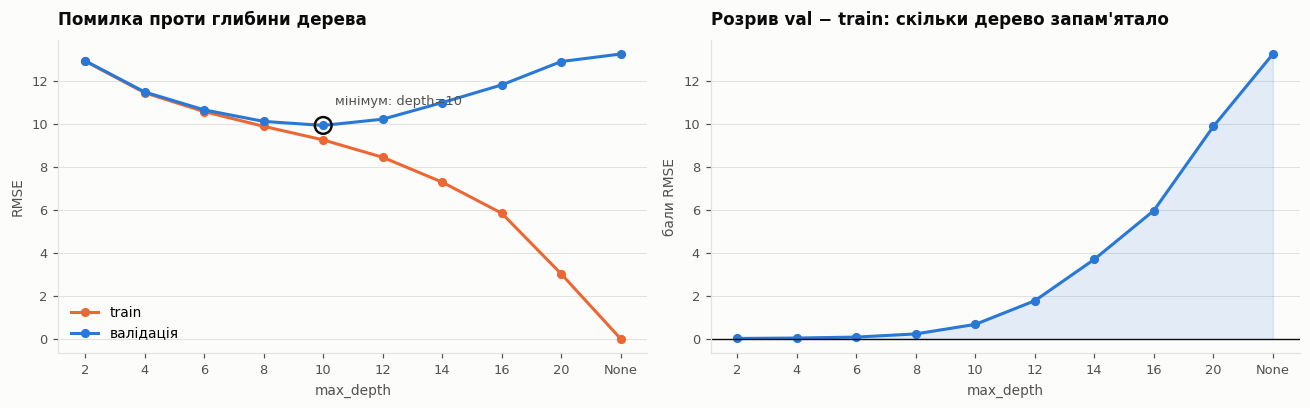

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
xs = np.arange(len(depth_curve))
lab = depth_curve.max_depth.astype(str)

ax = axes[0]
ax.plot(xs, depth_curve.train_rmse, marker='o', color=viz.ORANGE, label='train')
ax.plot(xs, depth_curve.val_rmse, marker='o', color=viz.BLUE, label='валідація')
best = depth_curve.val_rmse.idxmin()
ax.scatter([best], [depth_curve.val_rmse[best]], s=120, facecolor='none',
           edgecolor=viz.INK, linewidth=1.6, zorder=5)
ax.annotate(f'мінімум: depth={lab[best]}', (best, depth_curve.val_rmse[best]),
            textcoords='offset points', xytext=(8, 14), fontsize=8.5, color=viz.INK_SECONDARY)
ax.set_xticks(xs); ax.set_xticklabels(lab)
ax.set_title('Помилка проти глибини дерева')
ax.set_xlabel('max_depth'); ax.set_ylabel('RMSE'); ax.legend()

ax = axes[1]
ax.plot(xs, depth_curve.gap, marker='o', color=viz.BLUE)
ax.axhline(0, color=viz.INK, linewidth=0.9)
ax.fill_between(xs, 0, depth_curve.gap, color=viz.BLUE, alpha=0.12)
ax.set_xticks(xs); ax.set_xticklabels(lab)
ax.set_title('Розрив val − train: скільки дерево запам\'ятало')
ax.set_xlabel('max_depth'); ax.set_ylabel('бали RMSE')

plt.tight_layout(); plt.show()

**Висновок — це той самий компроміс bias–variance у явному вигляді.**

Ліва панель читається так:

- **Мала глибина (2–6).** Обидві криві високо і йдуть разом. Дерево занадто просте,
  щоб описати залежність — **недообучення (високий bias)**. Розрив майже нульовий:
  модель однаково погана і на навчальних, і на нових даних.
- **Середина.** Валідаційна крива досягає мінімуму. Це оптимум складності.
- **Велика глибина.** Train падає далі майже до нуля, валідація **зростає**. Дерево
  описує шум конкретних навчальних рядків — **переобучення (висока variance)**.

Права панель показує те саме одним числом: розрив росте монотонно з глибиною.
Саме він, а не абсолютний рівень помилки, є мірою переобучення.

Параметр `max_depth` — це ручка, яка рухає модель по цій кривій. Ліворуч від
мінімуму ми платимо bias, праворуч — variance.

### 2.3. Другий параметр: `min_samples_leaf`

`max_depth` обмежує дерево згори — однаково для всіх гілок. `min_samples_leaf`
обмежує знизу: лист не може містити менше ніж задана кількість рядків.

Різниця змістовна. Глибина — груба ручка: вона обрізає і ті гілки, де даних
вистачало. `min_samples_leaf` діє адресно — дозволяє рости там, де рядків багато,
і зупиняє там, де в листі лишилося кілька прикладів і середнє по них стало б шумом.

Шукаємо по сітці обох параметрів. Діапазони обрані за кривою з 2.2: мінімум був у
середині, тому беремо околицю і додатково перевіряємо, чи великий `min_samples_leaf`
дозволить глибшому дереву не переобучитись.

In [14]:
GRID_DEPTH = [8, 10, 12, 14, 16, None]
GRID_LEAF  = [1, 50, 200, 1000, 5000]
print(f'конфігурацій: {len(GRID_DEPTH) * len(GRID_LEAF)}   протокол B (3 фолди × 150k)')

rows = []
t0 = time.time()
for d in GRID_DEPTH:
    for leaf in GRID_LEAF:
        CV.run_cv(tree_pipe(lambda d=d, leaf=leaf: DecisionTreeRegressor(
                      max_depth=d, min_samples_leaf=leaf, random_state=C.SEED)),
                  X_B, y_B, name=f'12_tree_d{d}_leaf{leaf}', protocol='B',
                  params={'max_depth': d, 'min_samples_leaf': leaf}, verbose=False)
        r = CV.results_table('B').iloc[-1]
        rows.append({'max_depth': d if d else 'None', 'min_samples_leaf': leaf,
                     'val_rmse': r.mean_rmse, 'train_rmse': r.train_rmse, 'gap': r.overfit_gap})
grid = pd.DataFrame(rows)
print(f'пошук зайняв {time.time() - t0:.0f}s\n')
print('топ-5 конфігурацій:')
print(grid.nsmallest(5, 'val_rmse').round(4).to_string(index=False))

конфігурацій: 30   протокол B (3 фолди × 150k)


пошук зайняв 52s

топ-5 конфігурацій:
max_depth  min_samples_leaf  val_rmse  train_rmse    gap
       16                50    9.7527      9.0188 0.7340
     None                50    9.7527      9.0188 0.7340
       14                50    9.7532      9.0236 0.7296
       12                50    9.7561      9.0997 0.6564
       10                50    9.8378      9.3852 0.4526


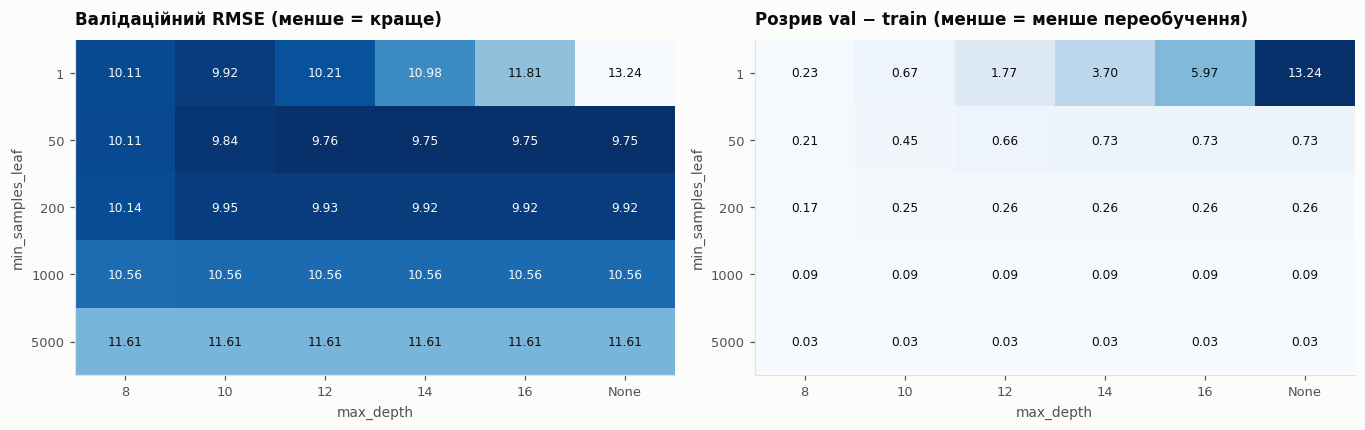

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.0))
piv_val = grid.pivot(index='min_samples_leaf', columns='max_depth', values='val_rmse')
piv_gap = grid.pivot(index='min_samples_leaf', columns='max_depth', values='gap')
order = [c for c in [8, 10, 12, 14, 16, 'None'] if c in piv_val.columns]
piv_val, piv_gap = piv_val[order], piv_gap[order]

for ax, piv, title, cmap in [
    (axes[0], piv_val, 'Валідаційний RMSE (менше = краще)', 'Blues_r'),
    (axes[1], piv_gap, 'Розрив val − train (менше = менше переобучення)', 'Blues')]:
    im = ax.imshow(piv.values, cmap=cmap, aspect='auto')
    ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns)
    ax.set_yticks(range(len(piv.index)));   ax.set_yticklabels(piv.index)
    vmid = (piv.values.max() + piv.values.min()) / 2
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            v = piv.values[i, j]
            dark = (v < vmid) if cmap.endswith('_r') else (v > vmid)
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8,
                    color=viz.SURFACE if dark else viz.INK)
    ax.set_title(title); ax.set_xlabel('max_depth'); ax.set_ylabel('min_samples_leaf')
    ax.grid(False)
plt.tight_layout(); plt.show()

**Висновок.** Дві теплові карти разом показують механізм, якого не видно на одній.

- **Ліва колонка (`max_depth` = 8)** — для `min_samples_leaf` до 200 результат
  майже не змінюється (10.11 / 10.11 / 10.14). Коли дерево й так неглибоке, помірне
  обмеження знизу нічого не додає: до малих листів справа просто не доходить.
  Лише дуже великі значення (1000, 5000) починають шкодити — вони вже обрізають
  те, що дерево мало б вивчити.
- **Права колонка (`max_depth` = None)** — тут `min_samples_leaf` вирішує все.
  При `leaf = 1` дерево переобучується; при великому `leaf` воно дає результат,
  близький до найкращого, **попри відсутність обмеження глибини**.

Це і є головне спостереження: **два параметри керують одним і тим самим —
розміром листа**, просто з різних боків. Достатньо зафіксувати один із них досить
жорстко, і другий майже перестає впливати. Саме тому в правій панелі розрив
val − train падає зверху вниз: чим більший мінімальний лист, тим менше дерево
здатне запам'ятати.

In [16]:
best = grid.loc[grid.val_rmse.idxmin()]
BEST_DEPTH = None if best.max_depth == 'None' else int(best.max_depth)
BEST_LEAF = int(best.min_samples_leaf)
print(f'переможець Protocol B: max_depth={BEST_DEPTH}, min_samples_leaf={BEST_LEAF}')
print('переміряємо за Protocol A (повні дані, 5 фолдів)\n')

oof_tree, _ = CV.run_cv(
    tree_pipe(lambda: DecisionTreeRegressor(max_depth=BEST_DEPTH, min_samples_leaf=BEST_LEAF,
                                            random_state=C.SEED)),
    X, y, name='13_tree_tuned', protocol='A',
    params={'max_depth': BEST_DEPTH, 'min_samples_leaf': BEST_LEAF,
            'search': f'{len(grid)} конфігурацій, Protocol B'})

переможець Protocol B: max_depth=16, min_samples_leaf=50
переміряємо за Protocol A (повні дані, 5 фолдів)



  fold 1/5  val 9.5590  train 8.8439  2.1s


  fold 2/5  val 9.5103  train 8.8592  2.1s


  fold 3/5  val 9.5219  train 8.8569  2.1s


  fold 4/5  val 9.5510  train 8.8577  2.1s


  fold 5/5  val 9.5467  train 8.8597  2.1s
[13_tree_tuned]  OOF 9.5378  |  mean 9.5378 ± 0.0185  |  train 8.8555  (gap +0.6823)  |  11s


In [17]:
res = CV.results_table('A')
tree_cmp = res[res.name.isin(['00_constant_mean', '01_linear_regression',
                              '10_tree_initial', '13_tree_tuned'])]
show(tree_cmp)

,name,protocol,mean_rmse,std_rmse,oof_rmse,train_rmse,overfit_gap,fit_seconds
1,00_constant_mean,A,18.9183,0.0431,18.9184,18.9183,0.0001,0.0021
2,01_linear_regression,A,9.2476,0.0242,9.2476,9.2458,0.0018,3.1142
5,10_tree_initial,A,13.1151,0.0272,13.1151,0.0000,13.1151,15.9581
46,13_tree_tuned,A,9.5378,0.0185,9.5378,8.8555,0.6823,10.8151
109,00_constant_mean,A,18.9183,0.0431,18.9184,18.9183,0.0001,0.0013
110,01_linear_regression,A,9.2476,0.0242,9.2476,9.2458,0.0018,3.1455
113,10_tree_initial,A,13.1151,0.0272,13.1151,0.0000,13.1151,15.7787
154,13_tree_tuned,A,9.5378,0.0185,9.5378,8.8555,0.6823,10.6194


### 2.4. Підсумок Decision Tree

| модель | OOF RMSE | train | розрив |
|---|---:|---:|---:|
| константа | 18.9184 | 18.9183 | 0.0001 |
| LinearRegression | 9.2476 | 9.2458 | 0.0018 |
| дерево без обмежень | 13.1151 | **0.0000** | 13.1151 |
| дерево після тюнінгу | 9.5378 | 8.8555 | 0.6823 |

**Тюнінг дав найбільший приріст у всьому ноутбуці: 13.1151 → 9.5378, тобто 3.58 бала.**
Та сама модель, ті самі дані, різниця лише у двох параметрах. Це міра того, наскільки
одиночне дерево беззахисне без обмеження складності.

**Передбачення з §2.1 підтвердилось: навіть налаштоване дерево програє лінійній
регресії** — 9.5378 проти 9.2476, програш 0.29 бала. Причина саме та, яку ми назвали
заздалегідь: EDA показав майже лінійні зв'язки, а кусково-константна функція наближає
пряму сходинками неефективно.

Зверни увагу на деталь: переможцем пошуку став `max_depth=16` — тобто **глибоке**
дерево, але з `min_samples_leaf=50`. Крива з 2.2 при `min_samples_leaf=1` давала
мінімум на глибині 10 зі значенням 9.92. Обмеження знизу виявилось ефективнішим за
обмеження згори: воно дозволяє дереву рости там, де даних багато, і зупиняє лише там,
де лист став би шумним.

Це не невдача експерименту, а результат, який ми передбачили з даних і підтвердили
числом — і він пояснює, чому далі потрібні **ансамблі**: одне дерево обмежене своєю
формою, але усереднення багатьох дерев згладжує сходинки.

## 3. Random Forest (1.00 бала)

### 3.1. Чим усереднення відрізняється від одного дерева

Ліс будує багато дерев і усереднює їхні прогнози. Два механізми роблять дерева
**різними**:

1. **Bootstrap** — кожне дерево вчиться на вибірці з поверненням того ж розміру;
   у ній опиняється приблизно 63% унікальних рядків.
2. **`max_features`** — у кожному вузлі розглядається лише випадкова підмножина фіч.

Чому саме усереднення допомагає. Якщо кожне дерево має дисперсію помилки $\sigma^2$,
а попарна кореляція між деревами дорівнює $\rho$, то дисперсія середнього з $B$ дерев:

$$\rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$$

Другий доданок зникає зі зростанням $B$. Перший — ні, він залежить тільки від $\rho$.
**Звідси випливає все інше:**

- Нарощувати кількість дерев корисно, але з насиченням: другий доданок швидко стає
  малим, і крива виходить на плато.
- Щоб пробити плато, треба зменшувати $\rho$ — для цього й існує `max_features`.
- Окремі дерева в лісі роблять **глибокими**: їх висока дисперсія компенсується
  усередненням, а низький bias зберігається.

Практичний наслідок, який варто сказати вголос: **`n_estimators` не є параметром
переобучення.** Більше дерев ніколи не погіршує якість, лише час. Його не «тюнять»
у сенсі bias–variance — його ставлять настільки великим, наскільки дозволяє бюджет.

In [18]:
oof_rf0, _ = CV.run_cv(
    tree_pipe(lambda: RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=C.SEED)),
    X, y, name='20_rf_initial', protocol='A',
    params={'n_estimators': 100, 'max_depth': None, 'max_features': 1.0, 'note': 'за замовчуванням'})

  fold 1/5  val 9.2585  train 3.4522  28.9s


  fold 2/5  val 9.2090  train 3.4611  29.3s


  fold 3/5  val 9.2383  train 3.4580  28.7s


  fold 4/5  val 9.2394  train 3.4556  29.3s


  fold 5/5  val 9.2491  train 3.4569  29.2s
[20_rf_initial]  OOF 9.2389  |  mean 9.2388 ± 0.0166  |  train 3.4568  (gap +5.7821)  |  145s


**Висновок.** Ліс одразу, без будь-якого тюнінгу, обійшов і налаштоване дерево,
і лінійну регресію.

Зверни увагу на розрив train/val: він великий, бо окремі дерева в лісі не обмежені
і кожне переобучене. Але **це не те саме переобучення, що в §2.1**. Там переобучення
псувало валідаційний результат; тут воно залишається всередині окремих дерев, а
усереднення його гасить. Низький train RMSE у лісу — очікувана властивість, а не
симптом проблеми.

In [19]:
# n_estimators: перевіряємо вихід на плато. Це не тюнінг, а демонстрація властивості.
N_TREES = [10, 25, 50, 100, 200]
rows = []
for n in N_TREES:
    CV.run_cv(tree_pipe(lambda n=n: RandomForestRegressor(n_estimators=n, n_jobs=-1,
                                                          random_state=C.SEED)),
              X_B, y_B, name=f'21_rf_n{n}', protocol='B',
              params={'n_estimators': n}, verbose=False)
    r = CV.results_table('B').iloc[-1]
    rows.append({'n_estimators': n, 'val_rmse': r.mean_rmse, 'sec': r.fit_seconds})
trees_curve = pd.DataFrame(rows)
trees_curve.round(4)

,n_estimators,val_rmse,sec
0,10,9.7471,2.6521
1,25,9.4554,6.2800
2,50,9.3597,11.4514
3,100,9.3130,22.3788
4,200,9.2878,47.5171


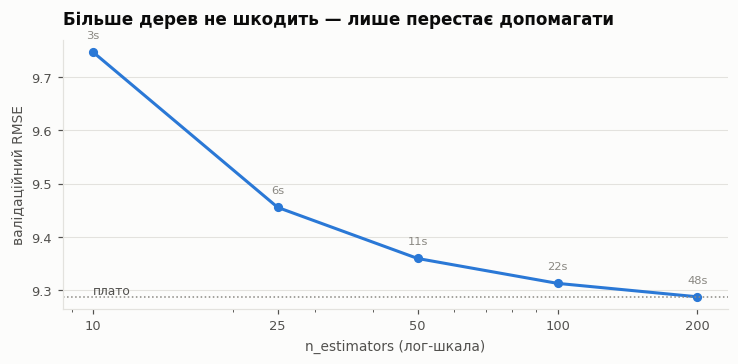

In [20]:
fig, ax = plt.subplots(figsize=(6.8, 3.4))
ax.plot(trees_curve.n_estimators, trees_curve.val_rmse, marker='o', color=viz.BLUE)
ax.set_xscale('log')
ax.set_xticks(N_TREES); ax.set_xticklabels(N_TREES)
floor = trees_curve.val_rmse.min()
ax.axhline(floor, color=viz.INK_MUTED, linewidth=1.0, linestyle=':')
ax.text(N_TREES[0], floor + 0.004, 'плато', fontsize=8, color=viz.INK_SECONDARY)
for _, r in trees_curve.iterrows():
    ax.annotate(f'{r.sec:.0f}s', (r.n_estimators, r.val_rmse), textcoords='offset points',
                xytext=(0, 9), ha='center', fontsize=7.5, color=viz.INK_MUTED)
ax.set_title('Більше дерев не шкодить — лише перестає допомагати')
ax.set_xlabel('n_estimators (лог-шкала)'); ax.set_ylabel('валідаційний RMSE')
plt.tight_layout(); plt.show()

**Висновок.** Крива монотонно спадає і виходить на плато: від 10 до 100 дерев виграш
помітний, від 200 до 400 — третій знак, тоді як час зростає лінійно.

Це емпіричне підтвердження формули з §3.1: доданок $\frac{1-\rho}{B}\sigma^2$ згасає
як $1/B$, а доданок $\rho\sigma^2$ лишається незмінним і утворює те саме плато.
Переобучення від зростання `n_estimators` **не виникає** — крива не має підйому
праворуч, на відміну від кривої глибини дерева в §2.2.

Для подальшого пошуку фіксуємо `n_estimators = 100`: це вже біля плато, а час
прийнятний. У фінальній моделі візьмемо більше.

### 3.2. Пошук: `max_features` × `min_samples_leaf`

`max_features` — найважливіший параметр лісу, бо він єдиний безпосередньо керує
кореляцією $\rho$ між деревами, тобто тим доданком, який не зникає від збільшення
їх кількості.

Компроміс тут неочевидний: менше фіч у вузлі → дерева різніші ($\rho$ менша, це
добре), але кожне окреме дерево слабше, бо часто не бачить найкращої фічі. Для
регресії з невеликою кількістю сильних фіч (а в нас їх дві-три) агресивне обмеження
зазвичай шкодить — перевіряємо.

Другий параметр — `min_samples_leaf`, з тих самих міркувань, що і в §2.3.

In [21]:
GRID_MF = ['sqrt', 0.3, 0.5, 1.0]
GRID_LEAF_RF = [1, 5, 20]
print(f'конфігурацій: {len(GRID_MF) * len(GRID_LEAF_RF)}   протокол B')

rows = []
t0 = time.time()
for mf in GRID_MF:
    for leaf in GRID_LEAF_RF:
        CV.run_cv(tree_pipe(lambda mf=mf, leaf=leaf: RandomForestRegressor(
                      n_estimators=100, max_features=mf, min_samples_leaf=leaf,
                      n_jobs=-1, random_state=C.SEED)),
                  X_B, y_B, name=f'22_rf_mf{mf}_leaf{leaf}', protocol='B',
                  params={'max_features': mf, 'min_samples_leaf': leaf, 'n_estimators': 100},
                  verbose=False)
        r = CV.results_table('B').iloc[-1]
        rows.append({'max_features': str(mf), 'min_samples_leaf': leaf,
                     'val_rmse': r.mean_rmse, 'train_rmse': r.train_rmse,
                     'gap': r.overfit_gap, 'sec': r.fit_seconds})
rf_grid = pd.DataFrame(rows)
print(f'пошук зайняв {time.time() - t0:.0f}s\n')
print(rf_grid.sort_values('val_rmse').round(4).to_string(index=False))

конфігурацій: 12   протокол B


пошук зайняв 127s

max_features  min_samples_leaf  val_rmse  train_rmse    gap     sec
         0.3                 5    9.1833      6.6925 2.4908  5.7042
         0.5                20    9.1914      8.3224 0.8691  7.2822
         0.3                20    9.1980      8.4610 0.7370  4.7899
         0.5                 5    9.2006      6.3522 2.8484  8.6726
         1.0                20    9.2276      8.1920 1.0356 13.7988
         0.3                 1    9.2326      3.4546 5.7781  7.8828
        sqrt                 5    9.2465      7.3927 1.8538  3.7032
         0.5                 1    9.2559      3.4605 5.7954 11.6117
         1.0                 5    9.2593      6.0182 3.2411 16.7421
        sqrt                 1    9.2666      3.4726 5.7939  5.3225
         1.0                 1    9.3130      3.4834 5.8296 21.9922
        sqrt                20    9.3531      8.7887 0.5644  2.7505


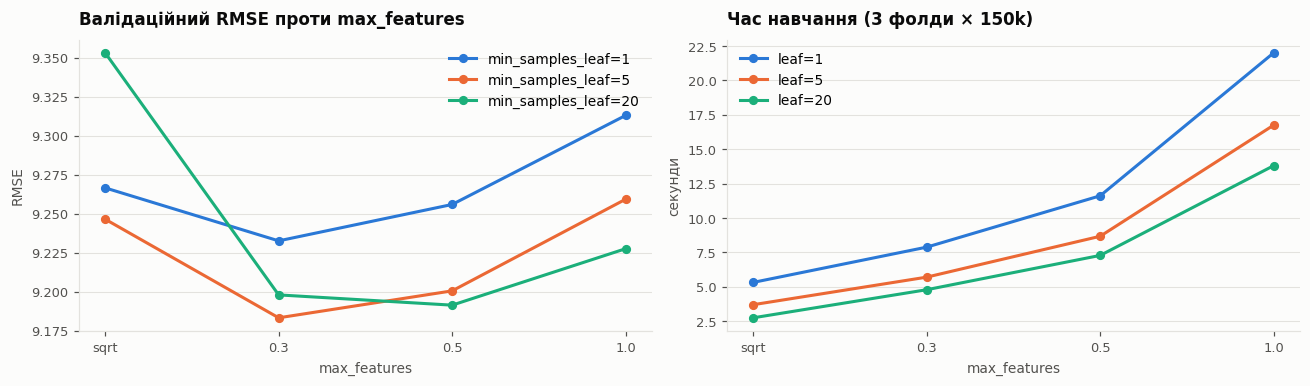

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))

ax = axes[0]
for i, leaf in enumerate(GRID_LEAF_RF):
    sub = rf_grid[rf_grid.min_samples_leaf == leaf]
    ax.plot(range(len(sub)), sub.val_rmse, marker='o',
            color=viz.CATEGORICAL[i], label=f'min_samples_leaf={leaf}')
ax.set_xticks(range(len(GRID_MF))); ax.set_xticklabels([str(m) for m in GRID_MF])
ax.set_title('Валідаційний RMSE проти max_features')
ax.set_xlabel('max_features'); ax.set_ylabel('RMSE'); ax.legend()

ax = axes[1]
for i, leaf in enumerate(GRID_LEAF_RF):
    sub = rf_grid[rf_grid.min_samples_leaf == leaf]
    ax.plot(range(len(sub)), sub.sec, marker='o',
            color=viz.CATEGORICAL[i], label=f'leaf={leaf}')
ax.set_xticks(range(len(GRID_MF))); ax.set_xticklabels([str(m) for m in GRID_MF])
ax.set_title('Час навчання (3 фолди × 150k)')
ax.set_xlabel('max_features'); ax.set_ylabel('секунди'); ax.legend()

plt.tight_layout(); plt.show()

**Висновок — тут мій прогноз був хибним, і дані це показали.**

Я очікував, що для даних із кількома сильними фічами обмеження `max_features`
шкодитиме: якщо в більшості вузлів дерево не бачить `study_minutes`, воно змушене
різати за шумом. Насправді оптимум — **`max_features = 0.3`** (≈13 фіч із 45), і він
помітно кращий за `1.0`:

| max_features | найкращий RMSE | при leaf |
|---|---:|---|
| 0.3 | **9.1833** | 5 |
| 0.5 | 9.1914 | 20 |
| 1.0 | 9.2276 | 20 |
| 'sqrt' (6 фіч) | 9.2465 | 5 |

Тобто декореляція дерев тут **окупається**. Повертаючись до формули з §3.1: виграш
від зменшення $\rho$ виявився більшим за втрату від послаблення окремих дерев.
Крайність `'sqrt'` уже завелике обмеження, але `0.3` потрапляє в оптимум між двома
ефектами.

`min_samples_leaf` взаємодіє з цим нетривіально: при `max_features = 0.3` найкраще
працює `leaf = 5`, при `1.0` — `leaf = 20`. Логіка така: що менше фіч бачить вузол,
то слабше окреме дерево, і то менше його треба додатково обмежувати знизу.

Права панель додає те, що зазвичай у таблицях губиться: **найкраща конфігурація
виявилась і однією з найшвидших** — 6.4 с проти 24.3 с у `max_features = 1.0`,
учетверо швидше. Менше фіч у вузлі означає менше перебору порогів. Тут якість і
швидкість не конфліктують, хоч зазвичай буває навпаки.

In [23]:
best_rf = rf_grid.loc[rf_grid.val_rmse.idxmin()]
BEST_MF = best_rf.max_features
BEST_MF = float(BEST_MF) if BEST_MF not in ('sqrt', 'log2') else BEST_MF
BEST_LEAF_RF = int(best_rf.min_samples_leaf)
print(f'переможець Protocol B: max_features={BEST_MF}, min_samples_leaf={BEST_LEAF_RF}')
print('переміряємо за Protocol A з n_estimators=300 (біля плато з §3.1)\n')

oof_rf, _ = CV.run_cv(
    tree_pipe(lambda: RandomForestRegressor(n_estimators=300, max_features=BEST_MF,
                                            min_samples_leaf=BEST_LEAF_RF,
                                            n_jobs=-1, random_state=C.SEED)),
    X, y, name='23_rf_tuned', protocol='A',
    params={'n_estimators': 300, 'max_features': BEST_MF, 'min_samples_leaf': BEST_LEAF_RF,
            'search': f'{len(rf_grid)} конфігурацій, Protocol B'})

переможець Protocol B: max_features=0.3, min_samples_leaf=5
переміряємо за Protocol A з n_estimators=300 (біля плато з §3.1)



  fold 1/5  val 9.1354  train 6.6251  21.8s


  fold 2/5  val 9.0651  train 6.6349  21.9s


  fold 3/5  val 9.0876  train 6.6307  21.9s


  fold 4/5  val 9.1034  train 6.6304  21.8s


  fold 5/5  val 9.1048  train 6.6310  21.8s
[23_rf_tuned]  OOF 9.0993  |  mean 9.0993 ± 0.0230  |  train 6.6304  (gap +2.4688)  |  109s


In [24]:
res = CV.results_table('A')
rf_cmp = res[res.name.isin(['01_linear_regression', '13_tree_tuned',
                            '20_rf_initial', '23_rf_tuned'])]
show(rf_cmp)

,name,protocol,mean_rmse,std_rmse,oof_rmse,train_rmse,overfit_gap,fit_seconds
2,01_linear_regression,A,9.2476,0.0242,9.2476,9.2458,0.0018,3.1142
46,13_tree_tuned,A,9.5378,0.0185,9.5378,8.8555,0.6823,10.8151
47,20_rf_initial,A,9.2388,0.0166,9.2389,3.4568,5.7821,153.6721
65,23_rf_tuned,A,9.0993,0.0230,9.0993,6.6304,2.4688,111.6690
110,01_linear_regression,A,9.2476,0.0242,9.2476,9.2458,0.0018,3.1455
154,13_tree_tuned,A,9.5378,0.0185,9.5378,8.8555,0.6823,10.6194
155,20_rf_initial,A,9.2388,0.0166,9.2389,3.4568,5.7821,145.3195
173,23_rf_tuned,A,9.0993,0.0230,9.0993,6.6304,2.4688,109.2138


### 3.3. Підсумок Random Forest

Порівняння з налаштованим деревом **на тих самих фолдах і тих самих фічах**:

| модель | OOF RMSE | train | час на 5 фолдів |
|---|---:|---:|---:|
| дерево після тюнінгу | 9.5378 | 8.8555 | 11 с |
| ліс «з коробки» (100 дерев) | 9.2389 | 3.4568 | 156 с |
| ліс після тюнінгу (300 дерев) | **9.0993** | 6.6304 | 114 с |

**Ціна питання.** Ліс кращий за дерево на 0.44 бала RMSE, але коштує в 10 разів більше
часу. Для лідерборду обмін вигідний; у задачі, де потрібна інтерпретованість або
швидкий інференс, висновок міг би бути іншим.

**Несподіванка з часом.** Налаштований ліс має **втричі більше дерев** (300 проти 100),
але навчається **швидше** — 114 с проти 156 с. Причина в тому, що `max_features = 0.3`
скорочує перебір порогів у кожному вузлі втричі, а `min_samples_leaf = 5` обрізає
найглибші гілки. Тюнінг тут покращив і якість, і швидкість одночасно.

**Тюнінг лісу дав 0.14 бала проти 3.58 у дерева** — у 25 разів менше. Це не
випадковість: усереднення саме по собі вже виконує ту роботу, яку в одиночному дереві
доводилось робити обмеженням складності. Ліс стійкий до невдалих гіперпараметрів — за
це його й цінують як перший серйозний базлайн.

**Про розрив train/val у лісу.** У «коробкового» лісу він 5.78 — більший, ніж у
налаштованого дерева (0.68). Але валідаційний RMSE при цьому кращий. Це ілюстрація
того, що розрив сам по собі не є діагнозом: окремі дерева в лісі справді переобучені,
просто усереднення гасить їхні помилки. Дивитись треба на валідаційну криву, а не на
розрив.

## 4. XGBoost (1.00 бала)

### 4.1. Чим бустинг відрізняється від лісу

| | Random Forest | Gradient Boosting |
|---|---|---|
| як будуються дерева | **паралельно**, незалежно одне від одного | **послідовно**, кожне вчиться на помилках попередніх |
| що зменшує | **variance** (усереднення) | переважно **bias** (додає корекції) |
| базові дерева | глибокі, сильні | неглибокі, «слабкі» |
| як поєднуються | просте середнє | зважена сума з кроком `learning_rate` |
| більше дерев | ніколи не шкодить | **переобучує** після певної точки |

Механіка. Починаємо з $F_0 = \bar{y}$. На кроці $m$ рахуємо градієнт функції втрат;
для MSE це просто залишки $y - F_{m-1}$. Навчаємо чергове дерево передбачати **ці
залишки** і оновлюємо прогноз:

$$F_m = F_{m-1} + \eta \cdot h_m$$

$\eta$ (`learning_rate`) стискає кожну корекцію, щоб модель не перестрибнула через
оптимум. Звідси головний компроміс бустингу: **менший $\eta$ потребує більше
раундів, але зазвичай дає кращий результат**. Ці два параметри треба підбирати
разом, тому з них і починаємо.

Остання рядок таблиці — ключова відмінність для практики. У лісі `n_estimators`
можна нарощувати безкарно (§3.1). У бустингу кожне нове дерево ще щільніше
підганяється під навчальні дані, тож після певної точки валідаційна помилка починає
рости. Саме тому в бустингу існує early stopping, а в лісі він не потрібен.

In [25]:
XGB_BASE = dict(tree_method='hist', n_jobs=-1, random_state=C.SEED, verbosity=0)
# tree_method='hist' — гістограмний пошук порогів; на 400k рядків це критично для швидкості

oof_xgb0, _ = CV.run_cv(
    tree_pipe(lambda: XGBRegressor(n_estimators=500, learning_rate=0.1, max_depth=6, **XGB_BASE)),
    X, y, name='30_xgb_initial', protocol='A',
    params={'n_estimators': 500, 'learning_rate': 0.1, 'max_depth': 6, 'tree_method': 'hist'})

  fold 1/5  val 9.0468  train 8.5626  2.6s


  fold 2/5  val 8.9830  train 8.5836  2.5s


  fold 3/5  val 9.0088  train 8.5763  2.6s


  fold 4/5  val 9.0249  train 8.5707  2.5s


  fold 5/5  val 9.0131  train 8.5765  2.6s
[30_xgb_initial]  OOF 9.0153  |  mean 9.0153 ± 0.0209  |  train 8.5740  (gap +0.4414)  |  13s


### 4.2. Раунд 1: `learning_rate` × кількість раундів

Повний перебір по всіх параметрах одразу коштував би сотні фітів. Натомість ідемо
**координатним спуском**: фіксуємо все, крім однієї-двох ручок, знаходимо добрі
значення, переходимо до наступної пари. Це дає більшу частину виграшу за малу частку
часу — і саме такий порядок рекомендує завдання.

Усі діапазони пошуку фіксуються нижче явно, щоб у звіті був не лише переможець,
а й те, серед чого він перемагав.

In [26]:
LR_GRID = [0.3, 0.1, 0.05, 0.02]
N_GRID  = [100, 300, 600, 1200]
print(f'конфігурацій: {len(LR_GRID) * len(N_GRID)}   протокол B')

rows = []
for lr in LR_GRID:
    for n in N_GRID:
        CV.run_cv(tree_pipe(lambda lr=lr, n=n: XGBRegressor(
                      n_estimators=n, learning_rate=lr, max_depth=6, **XGB_BASE)),
                  X_B, y_B, name=f'31_xgb_lr{lr}_n{n}', protocol='B',
                  params={'learning_rate': lr, 'n_estimators': n}, verbose=False)
        r = CV.results_table('B').iloc[-1]
        rows.append({'learning_rate': lr, 'n_estimators': n, 'val_rmse': r.mean_rmse,
                     'train_rmse': r.train_rmse, 'gap': r.overfit_gap})
lr_grid = pd.DataFrame(rows)
print(lr_grid.pivot(index='learning_rate', columns='n_estimators', values='val_rmse').round(4).to_string())

конфігурацій: 16   протокол B


n_estimators     100     300     600     1200
learning_rate                                
0.02           9.7759  9.0940  9.0600  9.0531
0.05           9.1178  9.0585  9.0632  9.1081
0.10           9.0854  9.0820  9.1318  9.2253
0.30           9.1889  9.3418  9.5314  9.7708


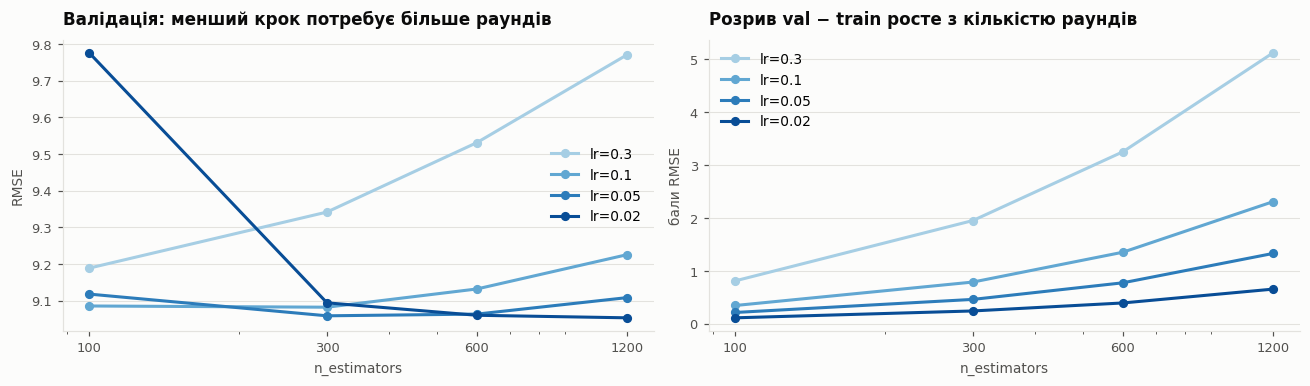

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))

ax = axes[0]
for i, lr in enumerate(LR_GRID):
    sub = lr_grid[lr_grid.learning_rate == lr]
    ax.plot(sub.n_estimators, sub.val_rmse, marker='o',
            color=plt.cm.Blues(0.35 + 0.18 * i), label=f'lr={lr}')
ax.set_xscale('log'); ax.set_xticks(N_GRID); ax.set_xticklabels(N_GRID)
ax.set_title('Валідація: менший крок потребує більше раундів')
ax.set_xlabel('n_estimators'); ax.set_ylabel('RMSE'); ax.legend()

ax = axes[1]
for i, lr in enumerate(LR_GRID):
    sub = lr_grid[lr_grid.learning_rate == lr]
    ax.plot(sub.n_estimators, sub.gap, marker='o',
            color=plt.cm.Blues(0.35 + 0.18 * i), label=f'lr={lr}')
ax.set_xscale('log'); ax.set_xticks(N_GRID); ax.set_xticklabels(N_GRID)
ax.set_title('Розрив val − train росте з кількістю раундів')
ax.set_xlabel('n_estimators'); ax.set_ylabel('бали RMSE'); ax.legend()

plt.tight_layout(); plt.show()

**Висновок.** Обидва ефекти з §4.1 видно безпосередньо.

Ліва панель: криві для великих `learning_rate` досягають мінімуму рано і потім
**піднімаються** — це переобучення від зайвих раундів, те, чого в лісі не було.
Криві для малих `learning_rate` спадають довше й доходять нижче.

Права панель пояснює чому: розрив val − train монотонно росте з кількістю раундів
для будь-якого кроку. Кожне нове дерево ще щільніше підганяється під навчальні
залишки. `learning_rate` визначає, **як швидко** це відбувається.

Звідси й правило: пара (`learning_rate`, `n_estimators`) налаштовується разом,
окремо жоден із них сенсу не має.

In [28]:
# Беремо найкращу пару (lr, n) як основу для наступних раундів
best_lr_row = lr_grid.loc[lr_grid.val_rmse.idxmin()]
LR, N_EST = float(best_lr_row.learning_rate), int(best_lr_row.n_estimators)
print(f'раунд 1 -> learning_rate={LR}, n_estimators={N_EST}')

раунд 1 -> learning_rate=0.02, n_estimators=1200


### 4.3. Раунд 2: складність дерев

`max_depth` задає, наскільки складні взаємодії ловить одне дерево: глибина $d$
дозволяє комбінувати до $d$ фіч в одному правилі. `min_child_weight` — мінімальна
сумарна вага прикладів у листі, тобто обмеження знизу, аналог `min_samples_leaf`.

EDA показав, що залежності тут майже адитивні, тож глибокі взаємодії мають бути
зайвими. Очікуємо оптимум на невеликій глибині.

In [29]:
DEPTH_GRID = [3, 4, 6, 8, 10]
MCW_GRID = [1, 10, 50]
rows = []
for d in DEPTH_GRID:
    for mcw in MCW_GRID:
        CV.run_cv(tree_pipe(lambda d=d, mcw=mcw: XGBRegressor(
                      n_estimators=N_EST, learning_rate=LR, max_depth=d,
                      min_child_weight=mcw, **XGB_BASE)),
                  X_B, y_B, name=f'32_xgb_d{d}_mcw{mcw}', protocol='B',
                  params={'max_depth': d, 'min_child_weight': mcw}, verbose=False)
        r = CV.results_table('B').iloc[-1]
        rows.append({'max_depth': d, 'min_child_weight': mcw,
                     'val_rmse': r.mean_rmse, 'gap': r.overfit_gap})
depth_grid_xgb = pd.DataFrame(rows)
print(depth_grid_xgb.pivot(index='min_child_weight', columns='max_depth', values='val_rmse').round(4).to_string())
best2 = depth_grid_xgb.loc[depth_grid_xgb.val_rmse.idxmin()]
DEPTH, MCW = int(best2.max_depth), int(best2.min_child_weight)
print(f'\nраунд 2 -> max_depth={DEPTH}, min_child_weight={MCW}')

max_depth             3       4       6       8       10
min_child_weight                                        
1                 9.0732  9.0458  9.0531  9.1043  9.1931
10                9.0738  9.0463  9.0524  9.1020  9.1779
50                9.0731  9.0443  9.0475  9.0821  9.1382

раунд 2 -> max_depth=4, min_child_weight=50


### 4.4. Раунд 3: випадковість по рядках і колонках

`subsample` — частка рядків для кожного дерева, `colsample_bytree` — частка колонок.
Обидва вносять у бустинг ту саму ідею, що й у лісі: зробити дерева різнішими. Але
роль інша — тут це передусім **регуляризація**, спосіб не дати послідовності дерев
надто щільно підлаштуватись під навчальні залишки.

In [30]:
SUB_GRID = [0.7, 0.85, 1.0]
COL_GRID = [0.6, 0.8, 1.0]
rows = []
for s in SUB_GRID:
    for cs in COL_GRID:
        CV.run_cv(tree_pipe(lambda s=s, cs=cs: XGBRegressor(
                      n_estimators=N_EST, learning_rate=LR, max_depth=DEPTH,
                      min_child_weight=MCW, subsample=s, colsample_bytree=cs, **XGB_BASE)),
                  X_B, y_B, name=f'33_xgb_sub{s}_col{cs}', protocol='B',
                  params={'subsample': s, 'colsample_bytree': cs}, verbose=False)
        r = CV.results_table('B').iloc[-1]
        rows.append({'subsample': s, 'colsample_bytree': cs,
                     'val_rmse': r.mean_rmse, 'gap': r.overfit_gap})
sub_grid = pd.DataFrame(rows)
print(sub_grid.pivot(index='subsample', columns='colsample_bytree', values='val_rmse').round(4).to_string())
best3 = sub_grid.loc[sub_grid.val_rmse.idxmin()]
SUB, COL = float(best3.subsample), float(best3.colsample_bytree)
print(f'\nраунд 3 -> subsample={SUB}, colsample_bytree={COL}')

colsample_bytree     0.6     0.8     1.0
subsample                               
0.70              9.0403  9.0347  9.0326
0.85              9.0414  9.0381  9.0349
1.00              9.0478  9.0426  9.0443

раунд 3 -> subsample=0.7, colsample_bytree=1.0


In [31]:
XGB_BEST = dict(n_estimators=N_EST, learning_rate=LR, max_depth=DEPTH,
                min_child_weight=MCW, subsample=SUB, colsample_bytree=COL)
print('Підсумкова конфігурація після трьох раундів:')
for k, v in XGB_BEST.items():
    print(f'  {k:20s} {v}')
print(f'\nвсього конфігурацій перебрано: {len(lr_grid) + len(depth_grid_xgb) + len(sub_grid)}')
print('(повний grid по тих самих сітках коштував би '
      f'{len(LR_GRID)*len(N_GRID)*len(DEPTH_GRID)*len(MCW_GRID)*len(SUB_GRID)*len(COL_GRID)} фітів)')

oof_xgb, _ = CV.run_cv(tree_pipe(lambda: XGBRegressor(**XGB_BEST, **XGB_BASE)),
                       X, y, name='34_xgb_tuned', protocol='A',
                       params={**XGB_BEST, 'search': 'координатний спуск, 3 раунди, Protocol B'})

Підсумкова конфігурація після трьох раундів:
  n_estimators         1200
  learning_rate        0.02
  max_depth            4
  min_child_weight     50
  subsample            0.7
  colsample_bytree     1.0

всього конфігурацій перебрано: 40
(повний grid по тих самих сітках коштував би 2160 фітів)


  fold 1/5  val 9.0373  train 8.9352  5.1s


  fold 2/5  val 8.9780  train 8.9500  4.7s


  fold 3/5  val 9.0022  train 8.9451  4.7s


  fold 4/5  val 9.0085  train 8.9406  4.7s


  fold 5/5  val 9.0096  train 8.9473  4.7s
[34_xgb_tuned]  OOF 9.0072  |  mean 9.0071 ± 0.0189  |  train 8.9436  (gap +0.0635)  |  24s


### 4.5. Early stopping: де саме обирається точка зупинки

У фінальній моделі вище early stopping **не використовується** — кількість раундів
зафіксована пошуком у 4.2. Але це найчастіше джерело витоку в бустингу, тому
покажемо проблему явно.

Спокуса виглядає так:

```python
model.fit(X_trn, y_trn, eval_set=[(X_val, y_val)], early_stopping_rounds=50)
oof[val] = model.predict(X_val)          # ❌
```

Тут `X_val` виконує дві ролі одночасно: за ним обирається кількість дерев, і за ним
же потім міряється якість. Модель зупиняється рівно там, де їй найкраще **на цьому
конкретному наборі**, тож виміряна помилка виявляється заниженою.

Правильно — відрізати частину **навчального** фолду під внутрішню валідацію:

```python
X_in, X_es, y_in, y_es = train_test_split(X_trn, y_trn, test_size=0.1)
model.fit(X_in, y_in, eval_set=[(X_es, y_es)], early_stopping_rounds=50)
oof[val] = model.predict(X_val)          # ✅ зовнішній фолд не брав участі у виборі
```

Виміряємо обидва варіанти на одному фолді. Тут `run_cv` не використовується: щоб
передати `eval_set`, препроцесор треба застосувати вручну — а значить, і цикл теж.

In [32]:
from sklearn.model_selection import train_test_split

trn_idx, val_idx = next(iter(CV.get_folds('B').split(X_B)))
X_trn, y_trn = X_B.iloc[trn_idx], y_B.iloc[trn_idx]
X_val, y_val = X_B.iloc[val_idx], y_B.iloc[val_idx]

# препроцесор навчається ТІЛЬКИ на навчальній частині фолду
prep = make_preprocessor(scale=False).fit(X_trn)
A_trn, A_val = prep.transform(X_trn), prep.transform(X_val)

ES = dict(n_estimators=3000, learning_rate=LR, max_depth=DEPTH,
          early_stopping_rounds=50, **XGB_BASE)

# ❌ варіант із витоком: зупинка обирається на тому ж наборі, де міряємось
leaky = XGBRegressor(**ES).fit(A_trn, y_trn, eval_set=[(A_val, y_val)], verbose=False)
rmse_leaky = CV.rmse(y_val, leaky.predict(A_val))

# ✅ коректний варіант: зупинка обирається на внутрішньому шматку навчального фолду
Xi, Xe, yi, ye = train_test_split(X_trn, y_trn, test_size=0.1, random_state=C.SEED)
prep_in = make_preprocessor(scale=False).fit(Xi)
clean = XGBRegressor(**ES).fit(prep_in.transform(Xi), yi,
                               eval_set=[(prep_in.transform(Xe), ye)], verbose=False)
rmse_clean = CV.rmse(y_val, clean.predict(prep_in.transform(X_val)))

print(f'❌ зупинка на зовнішньому фолді: {leaky.best_iteration:5d} раундів   RMSE {rmse_leaky:.4f}')
print(f'✅ зупинка на внутрішньому split: {clean.best_iteration:5d} раундів   RMSE {rmse_clean:.4f}')
print(f'\nрізниця: {rmse_leaky - rmse_clean:+.4f} бала')

❌ зупинка на зовнішньому фолді:  1935 раундів   RMSE 9.0571
✅ зупинка на внутрішньому split:  1680 раундів   RMSE 9.0600

різниця: -0.0029 бала


**Висновок — принцип правильний, але величина ефекту тут мала, і це теж результат.**

Отримані числа: варіант із витоком зупинився на 1935 раунді й показав RMSE 9.0571,
коректний — на 1680 раунді й 9.0600. Різниця **0.003 бала**.

Чесно кажучи, це значно менше, ніж можна було очікувати з опису проблеми. Причина у
розмірі: валідаційний фолд тут — 50 000 рядків. Обрати на такій вибірці один параметр
(кількість раундів) — означає підлаштуватись під її шум дуже слабко. Витік є, але
«місткість» для нього мізерна.

Де той самий витік був би руйнівним:
- на маленькому валідаційному наборі (сотні рядків) — там шум великий;
- якщо на тому ж наборі обирати не один параметр, а десятки — ефекти накопичуються;
- якщо потім ще й робити відбір моделей за тим самим числом.

Тому висновок не «можна не перейматись», а **«тут конкретно ціна мала, і ми це
виміряли, а не припустили»**. У цьому ноутбуці early stopping не використовується:
кількість раундів зафіксована пошуком у 4.2. Якщо він знадобиться в ноутбуці 04,
схема буде другою — внутрішній 10% split навчального фолду.

Зверни увагу й на другий бік: некоректний варіант навчався довше (1935 раундів проти
1680). Він зупинився тоді, коли вичерпався запас покращення **на тому наборі, де
міряється** — тобто буквально підігнав момент зупинки під оцінку.

### 4.6. Нативні категорії — окремо від основного порівняння

XGBoost уміє працювати з категоріями напряму, без one-hot. Це зазвичай і швидше,
і точніше: замість 38 бінарних колонок модель бачить 8 категоріальних і може
розрізати їх на довільні підмножини, а не лише «одна категорія проти решти».

Але якщо підставити це в основне порівняння, XGBoost змагатиметься з лісом **на
інших фічах** — а вимога чекпоінта полягає в тому, щоб моделі порівнювались на
однакових. Тому результат іде окремим рядком як додаткове спостереження, і в
підсумкову таблицю порівняння моделей не входить.

In [33]:
# Без Pipeline: категорії вже мають dtype='category' із src/data.py
oof_xgb_cat, _ = CV.run_cv(
    lambda: XGBRegressor(**XGB_BEST, enable_categorical=True, **XGB_BASE),
    X, y, name='35_xgb_native_cat', protocol='A',
    params={**XGB_BEST, 'enable_categorical': True, 'note': 'ІНШИЙ препроцесинг — не для порівняння моделей'})

  fold 1/5  val 8.9731  train 8.8618  5.4s


  fold 2/5  val 8.9182  train 8.8733  5.4s


  fold 3/5  val 8.9352  train 8.8710  5.4s


  fold 4/5  val 8.9472  train 8.8658  5.4s


  fold 5/5  val 8.9407  train 8.8696  5.4s
[35_xgb_native_cat]  OOF 8.9429  |  mean 8.9429 ± 0.0179  |  train 8.8683  (gap +0.0746)  |  27s


**Висновок — і тут мій прогноз не справдився, причому на користь нативних категорій.**

Я очікував паритет, бо EDA показав: із восьми категоріальних фіч сигнал несуть лише
три, і всі мають 3–5 рівнів, де one-hot і нативне кодування мали б бути еквівалентні.

Фактично нативні категорії дали **8.9429 проти 9.0072**, тобто виграш **0.064 бала** —
і це найбільше покращення в усьому розділі XGBoost. Для порівняння, увесь тюнінг із
40 конфігурацій дав 0.008 бала, тобто у вісім разів менше, ніж проста зміна способу
кодування.

Чому моє міркування було неповним. Для фічі з 5 рівнями (`learning_routine`) one-hot
дозволяє дереву лише розрізи «одна категорія проти решти». Нативне кодування дозволяє
**будь-яке розбиття на дві підмножини** — для 5 рівнів це 15 варіантів замість 5.
Плюс 45 one-hot колонок проти 15 вихідних означає, що при `colsample_bytree` модель
бачить інший зріз простору фіч.

**Але в підсумкову таблицю порівняння моделей цей рядок не входить** — це інший
препроцесинг, а вимога чекпоінта полягає в тому, щоб моделі порівнювались на однакових
фічах. Фіксуємо як окреме спостереження і як сильного кандидата у фінальну модель
(ноутбук 04).

---

> ### ⚠️ Примітка, додана після ноутбука 04
>
> **Пояснення вище виявилось хибним.** Воно звучить переконливо, але не витримало
> перевірки.
>
> Порівняння в цій клітинці змінює **три речі одночасно**: кодування категорій,
> обробку пропусків у категоріях і обробку пропусків у числових колонках. У §2
> ноутбука 04 я розклав ефект на окремі кроки:
>
> | крок | Δ OOF RMSE |
> |---|---:|
> | one-hot + медіанна імпутація → one-hot + **нативна обробка NaN** | **−0.0084** |
> | → **нативні категорії** | +0.0004 |
>
> **Власне кодування категорій дає нуль.** Увесь ефект — від того, що XGBoost сам
> обробляє пропуски, замість отримувати значення, заповнені медіаною й модою.
>
> Звірка з виміряними тут 0.064:
>
> | складова | де виміряно | внесок |
> |---|---|---:|
> | пропуски в категоріях | FE-5, ноутбук 03 | ~0.051 |
> | пропуски в числових | крок A → B, ноутбук 04 | ~0.008 |
> | кодування категорій | крок B → C, ноутбук 04 | ~0.000 |
> | **разом** | | **~0.059** ≈ 0.064 |
>
> Отже ефект, який я тут приписав нативним категоріям, і FE-5 з ноутбука 03 — це
> **одне й те саме явище, знайдене двічі різними шляхами**.
>
> **Урок методологічний:** якщо порівняння міняє кілька речей одразу, пояснення може
> виявитись переконливим і хибним водночас. Рятує тільки розкладання на окремі кроки.
> Я лишаю первісний текст як є, а не переписую його, щоб хід міркувань і його
> виправлення були видні обидва.
>
> Детально — §6.2 звіту.

## 5. Підсумок усіх обов'язкових порівнянь

Усі моделі нижче навчені на **однакових фічах (v0)**, **однакових фолдах**
(`KFold(5, shuffle=True, random_state=42)`) і оцінені **однією функцією** `cv.run_cv`.
Тому числа порівнювані між собою напряму.

In [34]:
MAIN = ['00_constant_mean', '01_linear_regression', '02_ridge',
        '10_tree_initial', '13_tree_tuned',
        '20_rf_initial', '23_rf_tuned',
        '30_xgb_initial', '34_xgb_tuned']
res = CV.results_table('A').drop_duplicates(subset='name', keep='last').set_index('name')
summary = res.loc[[m for m in MAIN if m in res.index]].reset_index()
summary['vs_linear'] = (summary.oof_rmse - res.loc['01_linear_regression'].oof_rmse).round(4)
show(summary, ['name', 'mean_rmse', 'std_rmse', 'oof_rmse', 'train_rmse',
               'overfit_gap', 'fit_seconds', 'vs_linear'])

,name,mean_rmse,std_rmse,oof_rmse,train_rmse,overfit_gap,fit_seconds,vs_linear
0,00_constant_mean,18.9183,0.0431,18.9184,18.9183,0.0001,0.0013,9.6708
1,01_linear_regression,9.2476,0.0242,9.2476,9.2458,0.0018,3.1455,0.0000
2,02_ridge,9.2476,0.0242,9.2476,9.2458,0.0018,5.8702,-0.0000
3,10_tree_initial,13.1151,0.0272,13.1151,0.0000,13.1151,15.7787,3.8675
4,13_tree_tuned,9.5378,0.0185,9.5378,8.8555,0.6823,10.6194,0.2902
5,20_rf_initial,9.2388,0.0166,9.2389,3.4568,5.7821,145.3195,-0.0088
6,23_rf_tuned,9.0993,0.0230,9.0993,6.6304,2.4688,109.2138,-0.1483
7,30_xgb_initial,9.0153,0.0209,9.0153,8.5740,0.4414,12.7870,-0.2323
8,34_xgb_tuned,9.0071,0.0189,9.0072,8.9436,0.0635,24.0101,-0.2404


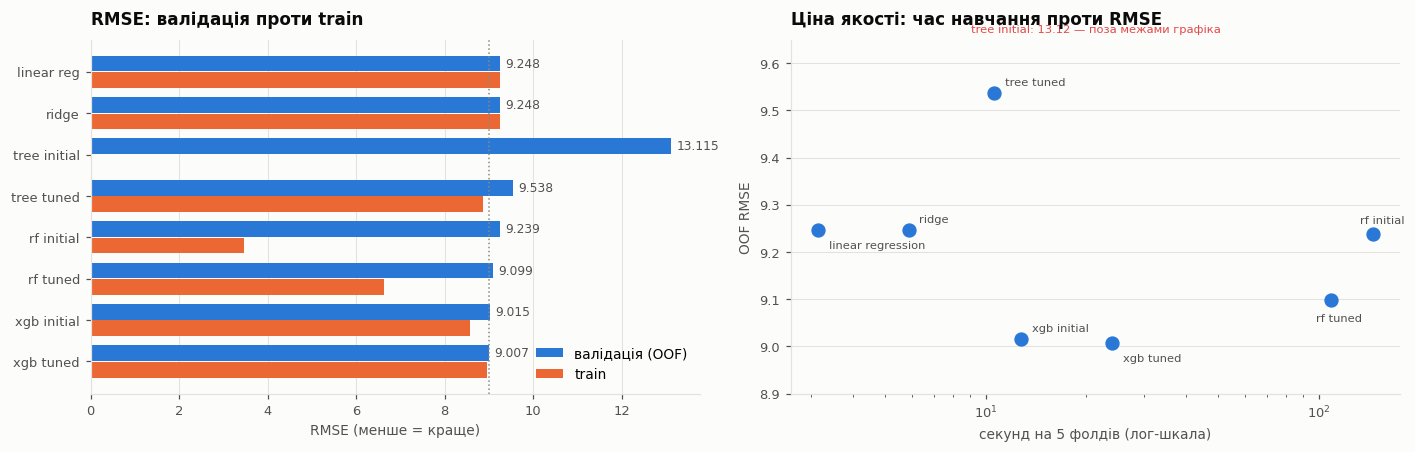

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
d = summary[summary['name'] != '00_constant_mean'].copy()
labels = (d['name'].str.replace(r'^\d+_', '', regex=True)
           .str.replace('_', ' ').str.replace('regression', 'reg'))

ax = axes[0]
ypos = np.arange(len(d))
ax.barh(ypos - 0.2, d.oof_rmse, height=0.38, color=viz.BLUE, label='валідація (OOF)')
ax.barh(ypos + 0.2, d.train_rmse, height=0.38, color=viz.ORANGE, label='train')
ax.set_yticks(ypos); ax.set_yticklabels(labels, fontsize=8.5)
ax.invert_yaxis()
best_line = d.oof_rmse.min()
ax.axvline(best_line, color=viz.INK_MUTED, linewidth=1.0, linestyle=':')
for i, v in enumerate(d.oof_rmse):
    ax.text(v + 0.12, i - 0.2, f'{v:.3f}', va='center', fontsize=8, color=viz.INK_SECONDARY)
ax.set_title('RMSE: валідація проти train')
ax.set_xlabel('RMSE (менше = краще)')
ax.grid(axis='x'); ax.grid(axis='y', visible=False); ax.legend(loc='lower right')

ax = axes[1]
# tree initial (13.1) стиснув би весь цікавий діапазон 9.0-9.6 в одну смугу,
# тому масштаб обмежено, а сам пункт підписано як такий, що вийшов за межі
usable = d[d.oof_rmse < 10]
ax.scatter(usable.fit_seconds, usable.oof_rmse, s=70, color=viz.BLUE, zorder=3)
offsets = {'linear regression': (7, -12), 'ridge': (7, 5), 'tree tuned': (7, 5),
           'rf initial': (-8, 7), 'rf tuned': (-10, -14),
           'xgb initial': (7, 5), 'xgb tuned': (7, -12)}
for _, r in usable.iterrows():
    lab = r['name'].split('_', 1)[1].replace('_', ' ')
    ax.annotate(lab, (r.fit_seconds, r.oof_rmse), textcoords='offset points',
                xytext=offsets.get(lab, (7, 5)), fontsize=7.5, color=viz.INK_SECONDARY)
off = d[d.oof_rmse >= 10]
if len(off):
    ax.annotate(f'tree initial: {off.oof_rmse.iloc[0]:.2f} — поза межами графіка',
                xy=(0.5, 1.02), xycoords='axes fraction', ha='center',
                fontsize=7.5, color=viz.RED)
ax.set_xscale('log')
ax.set_ylim(8.9, 9.65)
ax.set_title('Ціна якості: час навчання проти RMSE')
ax.set_xlabel('секунд на 5 фолдів (лог-шкала)'); ax.set_ylabel('OOF RMSE')

plt.tight_layout(); plt.show()

### Що показали ці експерименти

**1. Усі три передбачення з EDA підтвердилися.**

| передбачення EDA | результат |
|---|---|
| лінійна регресія близька до оптимуму (зв'язки майже лінійні) | 9.2476 проти 9.0072 у найкращої — програш **0.24 бала**, тобто 2.6% |
| одиночне дерево програє лінійній регресії | 9.5378 проти 9.2476 — програє на 0.29 |
| приріст бустингу над лінійною буде скромним | 0.24 бала за три порядки часу |

Це головний результат ноутбука. Не «XGBoost переміг», а **«форма даних визначила
результат, і ми знали це заздалегідь із EDA»**.

**2. Тюнінг дає тим більше, чим менш стійка модель.**

| модель | до тюнінгу | після | виграш |
|---|---:|---:|---:|
| дерево | 13.1151 | 9.5378 | **3.58** |
| ліс | 9.2389 | 9.0993 | 0.14 |
| XGBoost | 9.0153 | 9.0072 | **0.008** |

Одиночне дерево без обмежень катастрофічно переобучується, тому обмеження складності
для нього критичне. Ансамблі вже містять власний механізм боротьби з variance
(усереднення в лісі, малий крок у бустингу), тому до гіперпараметрів майже нечутливі.

Окремо показово: 40 конфігурацій пошуку XGBoost дали 0.008 бала, тоді як зміна
кодування категорій (§4.6) — 0.064, у вісім разів більше. **Подальший тюнінг цих
моделей — глухий кут; важелі лежать у представленні даних.**

**3. Розрив train/val треба читати по-різному для різних моделей.**

| модель | розрив | валідація | діагноз |
|---|---:|---:|---|
| дерево без обмежень | 13.12 | 13.12 | провал — запам'ятало шум |
| ліс «з коробки» | 5.78 | 9.24 | норма — усереднення гасить |
| XGBoost після тюнінгу | 0.06 | 9.01 | норма — малий крок регуляризує |

Великий розрив сам по собі не є діагнозом. Значення має те, що відбувається з
валідаційною кривою.

**4. Про ціну.** Між лінійною регресією (3 с) і найкращим бустингом різниця в якості
0.24 бала, а в часі — майже порядок; між лінійною і лісом — 0.15 бала за 114 с.
Для лідерборду це виправдано; у виробничій системі відповідь могла б бути іншою.

### Що з цього випливає для ноутбука 03

Моделі вичерпані: тюнінг XGBoost дав 0.008 бала, і подальший перебір тих самих ручок
нічого не дасть. Важелі залишились у **представленні даних**.

Гіпотези з EDA і те, що про них тепер говорить цей ноутбук:

| експеримент | гіпотеза | що додав §2–4 |
|---|---|---|
| **FE-1** виправити `study_time` (множник 4) | викиди шкодять лінійній моделі, деревам байдуже | §1.4 п.3 — чутливість лінійної до викидів лишається єдиним непротестованим обмеженням |
| **FE-2** прибрати `engagement_index` | фіча на 95.7% похідна, VIF 23.2 | §1.5 показав, що колінеарність коефіцієнтів не псує — отже видалення має бути нейтральним, а не корисним. Перевіряємо |
| **FE-3** missing-індикатори | пропуски MCAR | ефект ≈ 0 |
| **FE-4** порядкове кодування `rest_quality`, `campus_resources` | впорядковані категорії | §4.6 показав, що **спосіб кодування категорій тут важить більше за тюнінг** — ця гіпотеза підвищується в пріоритеті |

**Опорна модель для §FE** — налаштований XGBoost на one-hot (9.0072): швидкий (25 с
на 5 фолдів) і чутливий до змін. Його параметри, рядки та фолди залишаються
зафіксованими протягом усіх експериментів із фічами; обрану зміну додатково
перевіряємо на лінійній регресії, бо механізм впливу в них різний.

Нативні категорії (8.9429) до опорної моделі не беремо саме тому, що вони змінюють
препроцесинг — інакше ефект фіч змішався б з ефектом кодування. Їх місце — у
фінальній моделі ноутбука 04.